# Phase 1: One-Class SVM for Novelty Detection in Manufacturing
**Objective:** Implement a One-Class Support Vector Machine (OC-SVM) to identify defective products using only "normal" baseline data during training.

## 1. Environment Setup & Library Imports
In this section, we initialize our workspace. We will rely on:
* **`scikit-learn`**: For datasets, model building (OC-SVM, Isolation Forest), and performance metrics.
* **`scikit-image`**: For extracting Histogram of Oriented Gradients (HOG) features from images.
* **`numpy` & `pandas`**: For data manipulation and matrix operations.
* **`matplotlib`**: For visualizing our data and Precision-Recall curves.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, PrecisionRecallDisplay, precision_recall_curve, auc
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from skimage.feature import hog
import time
import joblib
import os


# This ensures matplotlib plots appear directly inside the notebook
%matplotlib inline

## 2. Data Acquisition & Preprocessing Pipeline
In traditional binary classification, models are trained on both healthy and defective examples. However, real-world manufacturing environments suffer from **extreme class imbalance** (e.g., 99.9% normal, 0.1% defective).

To simulate this using the MNIST dataset, we treat the digit **"1" as our "Normal" class** and all other digits as "Anomalies" (defects).
* **Training Set:** Consists strictly of normal data. The model learns the boundary of what constitutes a "healthy" state.
* **Testing Set:** Consists of unseen normal data mixed with a controlled percentage of anomalies (5%) to evaluate the model's precision and recall.

In [ ]:
# Define Data Pipeline
def load_and_preprocess_mnist():
    print("Fetching MNIST data via OpenML (this may take a minute on the first run)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data
    y = mnist.target

    print("Creating normal and anomaly splits...")
    # 1 for normal (inliers), -1 for anomalies (outliers)
    y_binary = np.where(y == '1', 1, -1)

    X_normal = X[y_binary == 1]
    X_anomaly = X[y_binary == -1]

    # Split: 80% train (pure normal), 20% test
    X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

    # Inject 5% anomalies into the test set
    anomaly_count = int(len(X_test_normal) * 0.05)
    X_test = np.vstack((X_test_normal, X_anomaly[:anomaly_count]))
    y_test = np.hstack((np.ones(len(X_test_normal)), -np.ones(anomaly_count)))

    # Shuffle test set
    shuffle_idx = np.random.permutation(len(X_test))
    X_test = X_test[shuffle_idx]
    y_test = y_test[shuffle_idx]

    return X_train_normal, X_test, y_test

## 3. Feature Extraction Modules
Raw pixel data often contains noise and redundant information, making it difficult for models to define clear decision boundaries. We implement two feature extraction techniques to compare against raw pixels:

1. **Principal Component Analysis (PCA):** A dimensionality reduction technique that compresses the data while retaining the majority of the variance (95%). This speeds up training and reduces the curse of dimensionality.
2. **Histogram of Oriented Gradients (HOG):** A computer vision technique that counts occurrences of gradient orientation. It is highly robust to lighting changes and is excellent for detecting physical shapes or surface defects (like scratches on manufactured parts).

In [ ]:
# Define Feature Extraction (PCA & HOG)
def extract_features_pca(X_train, X_test, variance_retained=0.95):
    print(f"Extracting PCA features (retaining {variance_retained*100}% variance)...")
    X_train_norm = X_train / 255.0
    X_test_norm = X_test / 255.0

    pca = PCA(n_components=variance_retained, random_state=42)
    X_train_pca = pca.fit_transform(X_train_norm)
    X_test_pca = pca.transform(X_test_norm)

    return X_train_pca, X_test_pca, pca

def extract_features_hog(X_data):
    print(f"Extracting HOG features for {len(X_data)} images...")
    hog_features = []
    # pixels per size affects model performance dramatically
    for i in range(len(X_data)):
        image = X_data[i].reshape((28, 28))
        fd = hog(image, orientations=8, pixels_per_cell=(4, 4),
                 cells_per_block=(1, 1), visualize=False)
        hog_features.append(fd)

    return np.array(hog_features)

## 4. Pipeline Execution (HOG Focus)
Here, we instantiate our data pipeline. Instead of relying on PCA, we will extract **HOG features for the entire dataset**.

Because HOG processes images patch-by-patch to calculate gradient vectors, running this on thousands of images is computationally intensive. *Note: This cell may take a few minutes to execute depending on your hardware.*

In [ ]:
# Execute the pipeline and extract HOG features
X_train_raw, X_test_raw, y_test = load_and_preprocess_mnist()

print(f"\nTraining set (Pure Normal): {X_train_raw.shape}")
print(f"Testing set (Mixed): {X_test_raw.shape}\n")

# Run HOG on the FULL datasets
# (This will take a little time as it processes thousands of images)
print("Starting HOG extraction for Training Set...")
X_train_hog = extract_features_hog(X_train_raw)

print("Starting HOG extraction for Testing Set...")
X_test_hog = extract_features_hog(X_test_raw)

print(f"\nHOG feature array shape (Train): {X_train_hog.shape}")
print(f"HOG feature array shape (Test): {X_test_hog.shape}")

Fetching MNIST data via OpenML (this may take a minute on the first run)...
Creating normal and anomaly splits...

Training set (Pure Normal): (6301, 784)
Testing set (Mixed): (1654, 784)

Starting HOG extraction for Training Set...
Extracting HOG features for 6301 images...
Starting HOG extraction for Testing Set...
Extracting HOG features for 1654 images...

HOG feature array shape (Train): (6301, 392)
HOG feature array shape (Test): (1654, 392)


## 5. Visual Sanity Check
Before feeding data into the OC-SVM, it is critical to confirm that our training set contains **no anomalies**. The following visualization samples the first five instances of our training data to ensure it consists entirely of our "Normal" class (the digit "1").

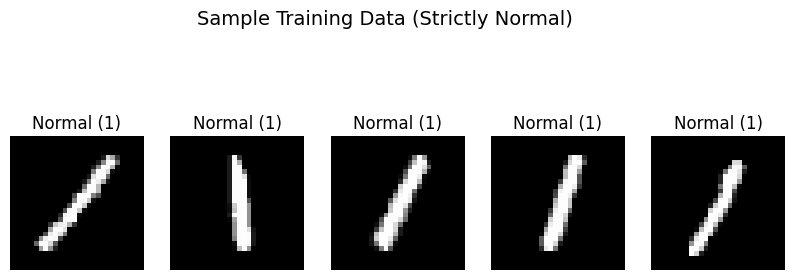

In [ ]:
# Let's visualize what the raw data looks like to confirm everything worked
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape the flat 784 array back into a 28x28 image
    plt.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
    plt.title("Normal (1)")
    plt.axis('off')
plt.suptitle("Sample Training Data (Strictly Normal)", fontsize=14)
plt.show()

# Phase 2: Model Implementation & Training

## 6. OC-SVM Initialization and Training (HOG Features)
We will train our One-Class SVM using the extracted HOG features (`X_train_hog`). In manufacturing, HOG is often vastly superior to raw pixels or PCA because it specifically highlights physical structures, edges, and textures (e.g., a crack in a component) while ignoring lighting variations.

**Key Parameters:**
* `kernel='rbf'`: The Radial Basis Function allows the model to create complex, non-linear boundaries.
* `nu=0.05`: We instruct the model to tolerate up to a 5% error rate on the training data. This prevents "overfitting" to the normal data by allowing a small buffer for natural, acceptable variations in the healthy manufacturing process.

In [ ]:
# Initialize and train the One-Class SVM on HOG features


print("Initializing One-Class SVM...")
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

print("Training model on strictly normal HOG data...")
start_time = time.time()

# We ONLY fit on the HOG training data.
oc_svm.fit(X_train_hog)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds.")

Initializing One-Class SVM...
Training model on strictly normal HOG data...
Training completed in 0.83 seconds.


## 7. Testing and Score Extraction
We now evaluate the model by passing our mixed testing set (`X_test_hog`) through the trained OC-SVM.

We extract two types of data:
1.  **Predictions:** Hard labels (`1` for normal, `-1` for anomaly).
2.  **Decision Scores:** Continuous values representing the distance of each part from the "healthy" boundary. We will use these scores later to optimize the model's threshold.

In [ ]:
# Predict on the test set using HOG features
print("Running predictions on the mixed test set...")

# Pass the HOG test features into the model
y_pred_test = oc_svm.predict(X_test_hog)

# Extract decision function scores
# predict uses the sign of decision_function internally (negative = anomaly) but metric functions need a score where higher = more anomalous. The negation bridges that gap
y_scores = -oc_svm.decision_function(X_test_hog)

print("Predictions and scores extracted successfully.")

Running predictions on the mixed test set...
Predictions and scores extracted successfully.


## 8. Performance Evaluation: Avoiding the Metric Trap
As noted in the project brief, accuracy is a misleading metric in extreme class imbalance. If our test set has a 5% defect rate, a model that blindly guesses "Normal" every time will be 95% accurate, but completely useless for predictive maintenance.

**Label Realignment:**
To use `sklearn`'s metric functions correctly, we must define the anomaly (defect) as our "Positive" class (`1`).
* **Original OC-SVM output:** `1` (Normal), `-1` (Anomaly)
* **Mapped output for metrics:** `0` (Normal/Negative), `1` (Anomaly/Positive)

In [ ]:
# Calculate Precision, Recall, and Accuracy


# Map True Labels: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
# One-Class SVM and scikit-learn's metrics use different label conventions, so this line bridges the gap between them.
# wherever the prediction is -1, put 1, otherwise put 0"
y_test_mapped = np.where(y_test == -1, 1, 0)

# Map Predictions: -1 (anomaly) becomes 1 (positive class), 1 (normal) becomes 0
y_pred_mapped = np.where(y_pred_test == -1, 1, 0)

# Calculate Metrics
accuracy = accuracy_score(y_test_mapped, y_pred_mapped)
precision = precision_score(y_test_mapped, y_pred_mapped)
recall = recall_score(y_test_mapped, y_pred_mapped)
f1 = f1_score(y_test_mapped, y_pred_mapped)

print("--- OC-SVM Performance on Test Set ---")
print(f"Accuracy:  {accuracy:.4f} (Misleading!)")
print(f"Precision: {precision:.4f} (When it flags a defect, is it actually a defect?)")
print(f"Recall:    {recall:.4f} (Out of all real defects, how many did it find?)")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_mapped, y_pred_mapped))

--- OC-SVM Performance on Test Set ---
Accuracy:  0.9498 (Misleading!)
Precision: 0.4843 (When it flags a defect, is it actually a defect?)
Recall:    0.9872 (Out of all real defects, how many did it find?)
F1-Score:  0.6498

Confusion Matrix:
[[1494   82]
 [   1   77]]


## 9. Precision-Recall (PR) Curve Visualization
The PR Curve illustrates how our HOG-trained model performs across different thresholds. In a real factory, adjusting this threshold balances two costs:
* **High Recall (Fewer False Negatives):** Catching every single defective part, but accidentally flagging some healthy parts (lowering precision).
* **High Precision (Fewer False Positives):** Only flagging a part if we are 100% sure it's broken, at the risk of letting a few defects slip through the assembly line.

<Figure size 800x600 with 0 Axes>

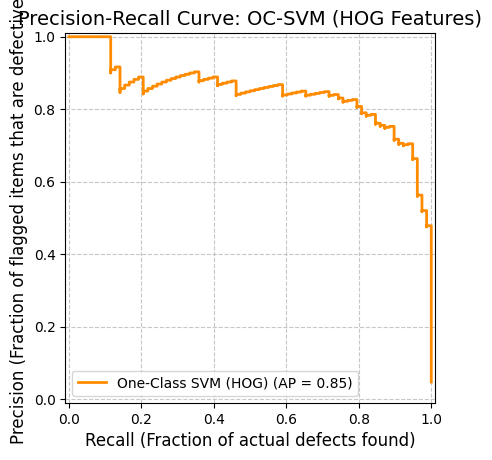

In [ ]:
# Plot the Precision-Recall Curve


plt.figure(figsize=(8, 6))

# Plot the PR curve using our HOG-based scores
display = PrecisionRecallDisplay.from_predictions(
    y_test_mapped,
    y_scores,
    name="One-Class SVM (HOG)",
    color="darkorange",
    linewidth=2
)

plt.title("Precision-Recall Curve: OC-SVM (HOG Features)", fontsize=14)
plt.xlabel("Recall (Fraction of actual defects found)", fontsize=12)
plt.ylabel("Precision (Fraction of flagged items that are defective)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()